**Cell 1 — Imports and configuration**

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BAYER_CSV = os.path.join(BASE_DIR, "BAYN_DE_log_returns.csv")
BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
SIE_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")
VOW_CSV = os.path.join(BASE_DIR, "VOW_DE_log_returns.csv")

**Cell 2 — Load and combine returns**

In [7]:
r_bayer = pd.read_csv(BAYER_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_sie = pd.read_csv(SIE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_vow = pd.read_csv(VOW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bayer, r_bmw, r_sie, r_vow], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens", "VOW"]
returns = returns.dropna()

print(f"Total observations (T): {len(returns)}")

Total observations (T): 7105


**Cell 3 — Standardize returns**

In [8]:
x1 = (returns["BMW"] - returns["BMW"].mean()) / returns["BMW"].std()
x2 = (returns["VOW"] - returns["VOW"].mean()) / returns["VOW"].std()

**Cell 4 — Scatter plot**

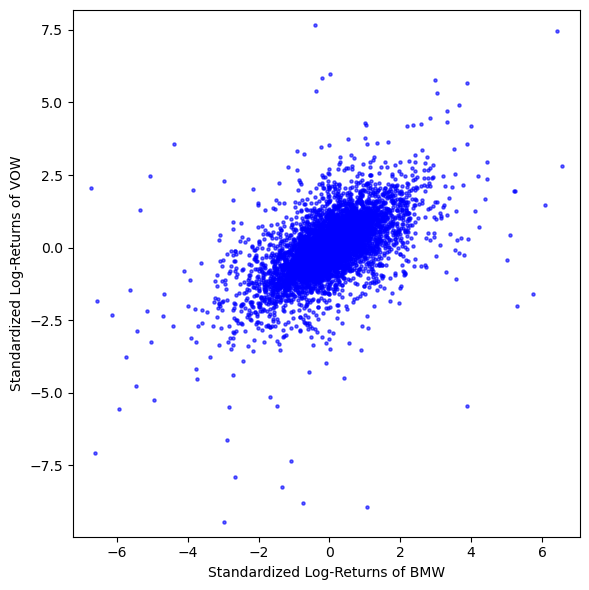

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x1, x2, color="blue", s=5, alpha=0.6, marker="o")

pad = 0.5
xlim = (x1.min() - pad, x1.max() + pad)
ylim = (x2.min() - pad, x2.max() + pad)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel("Standardized Log-Returns of BMW")
ax.set_ylabel("Standardized Log-Returns of VOW")
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "bmw_vow_scatter.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()

**Cell 5 — Kendall's tau and Spearman's rho for selected pairs**

In [10]:
pairs = [
    ("Bayer", "Siemens"),
    ("BMW", "VOW"),
    ("Siemens", "VOW"),
]

rank_corr_results = []
for a, b in pairs:
    tau, tau_p = kendalltau(returns[a], returns[b])
    rho, rho_p = spearmanr(returns[a], returns[b])
    rank_corr_results.append({
        "Pair": f"{a} - {b}",
        "tau": tau,
        "tau_pvalue": tau_p,
        "rho_s": rho,
        "rho_pvalue": rho_p,
    })

rank_corr_df = pd.DataFrame(rank_corr_results).set_index("Pair")
print(rank_corr_df.round(4))

                    tau  tau_pvalue   rho_s  rho_pvalue
Pair                                                   
Bayer - Siemens  0.3605         0.0  0.5000         0.0
BMW - VOW        0.4532         0.0  0.6103         0.0
Siemens - VOW    0.3388         0.0  0.4727         0.0


**Cell 6 — Save rank correlation results**

In [11]:
rank_corr_df.to_csv(os.path.join(OUTPUT_DIR, "rank_correlations.csv"))